# Perceptron Multi-Couches (PMC) — Cas d'images


## 1. Imports


In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

PYTHON_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'python'))
sys.path.insert(0, PYTHON_DIR)

from pmc import init, entrainer, predire, precision_pmc, lib as pmc_lib
from functions import load_dataset, melanger

project_root = os.path.abspath('..')
train_folder = os.path.join(project_root, 'dataset', 'train_dataset')
test_folder  = os.path.join(project_root, 'dataset', 'test_dataset')

print('Imports OK')


Imports OK


In [2]:
def courbe(x, y, xlabel, ylabel, titre, log=False):
    plt.plot(x, y, marker='o')
    if log:
        plt.xscale('log')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(titre)
    plt.show()


def courbe_train_test(hist_train, hist_test, ylabel, titre):
    plt.figure(figsize=(10, 5))
    plt.plot(hist_train, label='train')
    plt.plot(hist_test,  label='test')
    plt.xlabel('epoch')
    plt.ylabel(ylabel)
    plt.legend()
    plt.title(titre)
    plt.show()


def courbe_multi(historiques, couleurs, ylabel, titre):
    plt.figure(figsize=(10, 5))
    for cle, valeurs in historiques.items():
        resolution, couleur = cle
        label = f"{resolution}x{resolution} {'couleur' if couleur else 'gris'}"
        plt.plot(range(1, len(valeurs)+1), valeurs, label=label, color=couleurs[cle])
    plt.xlabel('epoch')
    plt.ylabel(ylabel)
    plt.title(titre)
    plt.legend(loc='lower right')
    plt.show()


## 2. Dataset


In [3]:
configs = {}
for resolution in (16, 32):
    for couleur in (False, True):
        X_train, Y_train = load_dataset(train_folder, target_size=(resolution, resolution), color=couleur, one_hot=True)
        X_test,  Y_test  = load_dataset(test_folder,  target_size=(resolution, resolution), color=couleur, one_hot=True)
        X_train, Y_train = melanger(X_train, Y_train, seed=42)
        configs[(resolution, couleur)] = (X_train, Y_train, X_test, Y_test)

for cle, (X_train, Y_train, X_test, Y_test) in configs.items():
    print(f'{cle}: train={len(X_train)}, test={len(X_test)}')


(16, False): train=2400, test=600
(16, True): train=2400, test=600
(32, False): train=2400, test=600
(32, True): train=2400, test=600


## 3. Exploration (résolution / couleur / epochs)

On entraîne chaque config sur `EPOCHS_EXPLO` epochs avec suivi train/test à chaque epoch,
puis on trace les courbes pour choisir la meilleure résolution.


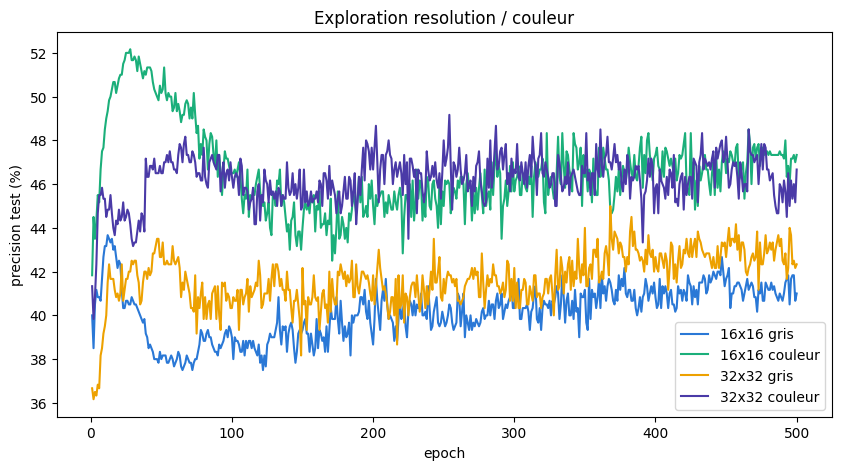

In [4]:
EPOCHS_EXPLO = 500
LR           = 0.01
NB_CLASSES   = 3

couleurs_courbe = {
    (16, False): '#2a78d6',
    (16, True):  '#1baf7a',
    (32, False): '#eda100',
    (32, True):  '#4a3aa7',
}

historiques = {}
for cle, (X_train, Y_train, X_test, Y_test) in configs.items():
    resolution, couleur = cle
    nb_entrees = resolution * resolution * (3 if couleur else 1)
    init(nb_entrees, 16, NB_CLASSES)
    _, hist_test, _, _ = entrainer(
        X_train, Y_train, epochs=EPOCHS_EXPLO, alpha=LR,
        X_test=X_test, Y_test=Y_test
    )
    historiques[cle] = hist_test

courbe_multi(historiques, couleurs_courbe, 'precision test (%)', 'Exploration resolution / couleur')


In [5]:
recap = []
for (resolution, couleur), hist_test in historiques.items():
    meilleur_epoch = int(np.argmax(hist_test)) + 1
    recap.append((resolution, couleur, meilleur_epoch, hist_test[meilleur_epoch - 1]))

recap.sort(key=lambda r: r[3], reverse=True)

print(f"{'Config':<16}{'Epoch':>7}{'Test%':>8}")
for resolution, couleur, epoch, acc in recap:
    config = f"{resolution}x{resolution} {'couleur' if couleur else 'gris'}"
    print(f"{config:<16}{epoch:>7}{acc:>7.2f}%")


Config            Epoch   Test%
16x16 couleur        28  52.17%
32x32 couleur       254  49.17%
32x32 gris          368  45.00%
16x16 gris           12  43.67%


## 4. Affinage (learning rate)

On prend la meilleure config trouvée en section 3 et on fait varier le learning rate.


lr=0.1 -> test=46.50%
lr=0.01 -> test=50.00%
lr=0.001 -> test=46.33%
lr=0.0001 -> test=38.83%
lr=1e-05 -> test=34.67%


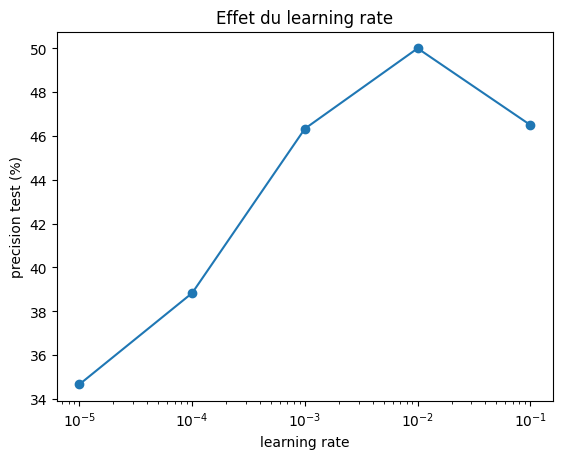

Meilleur lr : 0.01


In [6]:
# Meilleure config
best_resolution, best_couleur, meilleur_epoch, _ = recap[0]
X_train, Y_train, X_test, Y_test = configs[(best_resolution, best_couleur)]
nb_entrees_best = best_resolution * best_resolution * (3 if best_couleur else 1)

lrs = [0.1, 0.01, 0.001, 0.0001, 0.00001]
accs_lr = []

for lr in lrs:
    init(nb_entrees_best, 16, NB_CLASSES)
    entrainer(X_train, Y_train, epochs=meilleur_epoch, alpha=lr)
    accs_lr.append(precision_pmc(X_test, Y_test, NB_CLASSES))
    print(f'lr={lr} -> test={accs_lr[-1]:.2f}%')

meilleur_lr = lrs[int(np.argmax(accs_lr))]
courbe(lrs, accs_lr, 'learning rate', 'precision test (%)', 'Effet du learning rate', log=True)
print(f'Meilleur lr : {meilleur_lr}')


## 5. Modèle final

Entraînement avec la meilleure config (résolution, epochs, lr) trouvée aux sections 3 et 4.
On trace les courbes train/test et la matrice de confusion.


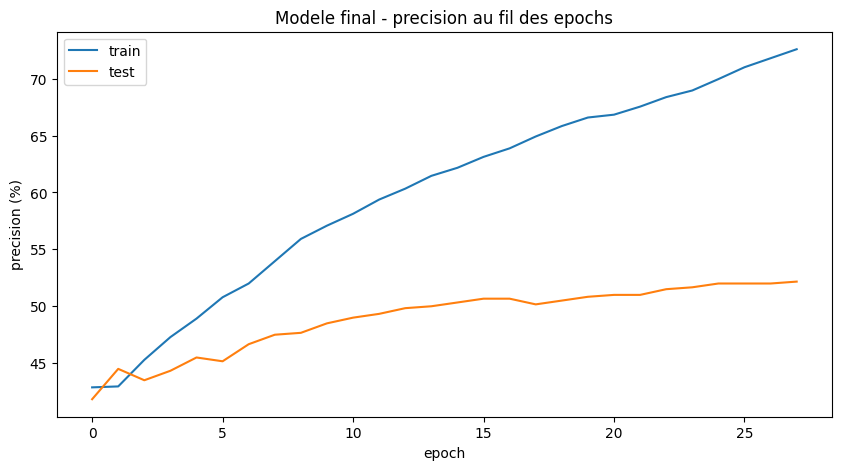

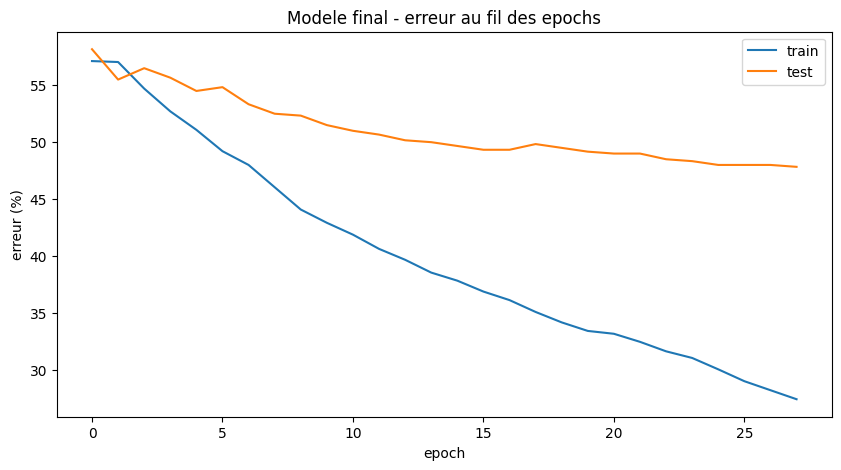

train=72.58%  test=52.17%


In [7]:
init(nb_entrees_best, 16, NB_CLASSES)
hist_train, hist_test, err_train, err_test = entrainer(
    X_train, Y_train, epochs=meilleur_epoch, alpha=meilleur_lr,
    X_test=X_test, Y_test=Y_test
)

courbe_train_test(hist_train, hist_test, 'precision (%)', 'Modele final - precision au fil des epochs')
courbe_train_test(err_train,  err_test,  'erreur (%)',    'Modele final - erreur au fil des epochs')

print(f'train={hist_train[-1]:.2f}%  test={hist_test[-1]:.2f}%')


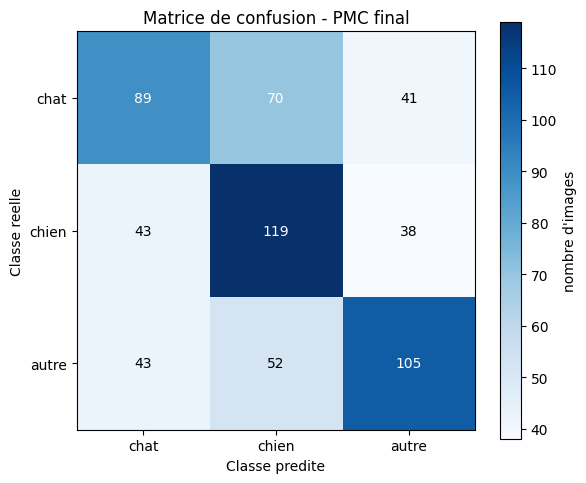

In [8]:
noms_classes = ['chat', 'chien', 'autre']

def matrice_confusion(X, Y, nb_classes=3):
    matrice = np.zeros((nb_classes, nb_classes), dtype=int)
    for x, y_vrai in zip(X, Y):
        y_pred = int(np.argmax(predire(x, nb_classes)))
        y_reel = int(np.argmax(y_vrai))
        matrice[y_reel][y_pred] += 1
    return matrice

cm = matrice_confusion(X_test, Y_test)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(noms_classes)))
ax.set_yticks(range(len(noms_classes)))
ax.set_xticklabels(noms_classes)
ax.set_yticklabels(noms_classes)
ax.set_xlabel('Classe predite')
ax.set_ylabel('Classe reelle')
ax.set_title('Matrice de confusion - PMC final')

seuil = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        couleur_texte = 'white' if cm[i, j] > seuil else 'black'
        ax.text(j, i, cm[i, j], ha='center', va='center', color=couleur_texte)

fig.colorbar(im, ax=ax, label="nombre d'images")
plt.tight_layout()
plt.show()


## 6. Sauvegarde du modèle

On sauvegarde le modèle final puis on le recharge pour vérifier que la précision est identique.


In [9]:
chemin = os.path.join(project_root, 'models', 'pmc_chat_chien_autre.txt')
os.makedirs(os.path.dirname(chemin), exist_ok=True)
pmc_lib.py_sauvegarder(chemin.encode())
print(f'Modele sauvegarde : {chemin}')

# Rechargement et verification
pmc_lib.py_charger(chemin.encode())
acc_recharge = precision_pmc(X_test, Y_test, NB_CLASSES)
print(f'test_acc (modele recharge) = {acc_recharge:.2f}%')


Modele sauvegarde : c:\Users\Shun\Desktop\Projet_Annual_IA-main\models\pmc_chat_chien_autre.txt
test_acc (modele recharge) = 52.17%
